In [1]:
# ============================================================
# WEEK 3 — Deep Reinforcement Learning (DQN)
# Project 2: Travel & Hospitality — RL Dynamic Pricing
# Intern Branch: preeti-dev | Infotact Solutions
#
# Roadmap requirement:
#   "Replace the Q-table with a Neural Network (Deep Q-Network).
#    Handle exploration-exploitation trade-off using epsilon-
#    greedy strategy and implement experience replay to
#    stabilize training."
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["gymnasium", "torch", "numpy", "matplotlib", "seaborn", "pandas", "tqdm"]:
    install(lib)
 
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import pickle
import os
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
 
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../data',    exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
print("✅ All libraries imported successfully")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {device}")

✅ All libraries imported successfully
   PyTorch version : 2.8.0+cpu
   Device          : cpu


In [2]:
# ── CELL 2: Re-define Environment (standalone copy) ──────
MARKET_EVENTS = {
    0: {'name': 'Normal',          'demand_multiplier': 1.0,  'color': '#60a5fa'},
    1: {'name': 'Holiday Surge',   'demand_multiplier': 1.6,  'color': '#34d399'},
    2: {'name': 'Competitor Sale', 'demand_multiplier': 0.6,  'color': '#f87171'},
    3: {'name': 'Bad Weather',     'demand_multiplier': 0.75, 'color': '#fbbf24'},
}
EVENT_PROBS = [0.65, 0.12, 0.15, 0.08]
 
CUSTOMER_SEGMENTS = {
    'business':     {'price_sensitivity':0.3, 'booking_window':'any',   'base_probability':0.25},
    'leisure':       {'price_sensitivity':0.9, 'booking_window':'early', 'base_probability':0.50},
    'last_minute':   {'price_sensitivity':0.2, 'booking_window':'late',  'base_probability':0.25},
}
 
SAFETY_CONFIG = {
    'eco_floor_idx':1, 'eco_ceiling_idx':7,
    'biz_floor_idx':1, 'biz_ceiling_idx':7,
    'max_daily_swing':3, 'violation_penalty':25.0
}
 
class ContextualAirlinePricingEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    ECO_PRICES        = [50, 100, 150, 200, 250, 300, 350, 400]
    BIZ_PRICES        = [300, 450, 600, 750, 900, 1050, 1100, 1200]
    COMPETITOR_PRICES = [80, 120, 160, 200, 240, 280, 320, 360]
 
    def __init__(self, eco_seats=40, biz_seats=10, total_days=30,
                 safety_config=SAFETY_CONFIG, render_mode=None):
        super().__init__()
        self.eco_seats_init, self.biz_seats_init = eco_seats, biz_seats
        self.total_days, self.render_mode, self.safety = total_days, render_mode, safety_config
        self.action_space = spaces.MultiDiscrete([len(self.ECO_PRICES), len(self.BIZ_PRICES)])
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0], dtype=np.float32),
            high=np.array([eco_seats,biz_seats,total_days,
                          len(self.COMPETITOR_PRICES)-1,len(MARKET_EVENTS)-1], dtype=np.float32),
            dtype=np.float32)
        self._init_state()
 
    def _init_state(self):
        self.eco_seats, self.biz_seats = self.eco_seats_init, self.biz_seats_init
        self.days_left = self.total_days
        self.total_revenue = self.eco_revenue = self.biz_revenue = 0.0
        self.market_event_id, self.competitor_idx = 0, 3
        self.prev_eco_idx = self.prev_biz_idx = 4
        self.safety_violations = 0
        self.history = []
 
    def _sample_market_event(self):
        return int(np.random.choice(len(MARKET_EVENTS), p=EVENT_PROBS))
 
    def _update_competitor_price(self):
        drift = np.random.choice([-1,0,0,1])
        self.competitor_idx = int(np.clip(self.competitor_idx+drift, 0, len(self.COMPETITOR_PRICES)-1))
 
    def _apply_safety_bounds(self, eco_idx, biz_idx):
        violated = False
        safe_eco = int(np.clip(eco_idx, self.safety['eco_floor_idx'], self.safety['eco_ceiling_idx']))
        safe_biz = int(np.clip(biz_idx, self.safety['biz_floor_idx'], self.safety['biz_ceiling_idx']))
        if safe_eco != eco_idx or safe_biz != biz_idx: violated = True
        max_swing = self.safety['max_daily_swing']
        if abs(safe_eco - self.prev_eco_idx) > max_swing:
            safe_eco = int(np.clip(self.prev_eco_idx + max_swing*np.sign(safe_eco-self.prev_eco_idx),
                                   0, len(self.ECO_PRICES)-1)); violated = True
        if abs(safe_biz - self.prev_biz_idx) > max_swing:
            safe_biz = int(np.clip(self.prev_biz_idx + max_swing*np.sign(safe_biz-self.prev_biz_idx),
                                   0, len(self.BIZ_PRICES)-1)); violated = True
        return safe_eco, safe_biz, violated
 
    def _segment_demand(self, price, days_left, seat_class, event_mult):
        max_price = max(self.BIZ_PRICES) if seat_class=='biz' else max(self.ECO_PRICES)
        total = 0
        for seg_name, seg in CUSTOMER_SEGMENTS.items():
            if seg['booking_window']=='late' and days_left>7: continue
            if seg['booking_window']=='early' and days_left<3: continue
            price_factor = max(0.0, 1.0 - seg['price_sensitivity']*(price/max_price))
            if seg_name=='last_minute': urgency = np.exp(-days_left/3)
            elif seg_name=='business':  urgency = 0.6+0.4*np.exp(-days_left/15)
            else:                      urgency = 1.0-0.6*np.exp(-days_left/20)
            competitor_eco = self.COMPETITOR_PRICES[self.competitor_idx]
            comp_factor = float(np.clip(1.0+0.3*(competitor_eco-price)/max_price, 0.5, 1.8))
            prob = seg['base_probability']*price_factor*urgency*comp_factor*event_mult + np.random.uniform(-0.05,0.05)
            prob = float(np.clip(prob, 0.0, 1.0))
            arrivals = np.random.randint(0,4)
            total += sum(np.random.random()<prob for _ in range(arrivals))
        return total
 
    def _get_obs(self):
        return np.array([self.eco_seats,self.biz_seats,self.days_left,
                         self.competitor_idx,self.market_event_id], dtype=np.float32)
 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._init_state()
        self.market_event_id = self._sample_market_event()
        self._update_competitor_price()
        return self._get_obs(), {}
 
    def step(self, action):
        raw_eco, raw_biz = int(action[0]), int(action[1])
        eco_idx, biz_idx, violated = self._apply_safety_bounds(raw_eco, raw_biz)
        eco_price, biz_price = self.ECO_PRICES[eco_idx], self.BIZ_PRICES[biz_idx]
        event = MARKET_EVENTS[self.market_event_id]; event_mult = event['demand_multiplier']
        eco_bk = min(self._segment_demand(eco_price,self.days_left,'eco',event_mult), self.eco_seats)
        biz_bk = min(self._segment_demand(biz_price,self.days_left,'biz',event_mult), self.biz_seats)
        eco_rev, biz_rev = eco_price*eco_bk, biz_price*biz_bk
        daily_rev = eco_rev+biz_rev
        penalty = self.safety['violation_penalty'] if violated else 0.0
        if violated: self.safety_violations += 1
        reward = daily_rev - penalty
        self.eco_seats -= eco_bk; self.biz_seats -= biz_bk
        self.total_revenue += daily_rev; self.eco_revenue += eco_rev; self.biz_revenue += biz_rev
        self.days_left -= 1; self.prev_eco_idx, self.prev_biz_idx = eco_idx, biz_idx
        self.market_event_id = self._sample_market_event(); self._update_competitor_price()
        self.history.append({
            'day':self.total_days-self.days_left, 'days_left':self.days_left+1,
            'eco_price':eco_price,'biz_price':biz_price,
            'competitor_price':self.COMPETITOR_PRICES[self.competitor_idx],
            'market_event':event['name'],'eco_bookings':eco_bk,'biz_bookings':biz_bk,
            'eco_rev':eco_rev,'biz_rev':biz_rev,'daily_revenue':daily_rev,
            'safety_violated':violated,'eco_seats_left':self.eco_seats,
            'biz_seats_left':self.biz_seats,'total_revenue':self.total_revenue})
        terminated = (self.days_left==0 or (self.eco_seats==0 and self.biz_seats==0))
        return self._get_obs(), reward, terminated, False, {}
 
    def get_history_df(self):
        return pd.DataFrame(self.history)
 
print("✅ Environment re-loaded (same as Week 1/2, standalone copy)")
 

✅ Environment re-loaded (same as Week 1/2, standalone copy)


In [3]:
# ── CELL 3: Load Week 2 Results for Comparison ───────────
try:
    week2_comparison = pd.read_csv('../data/week2_strategy_comparison.csv')
    print("✅ Week 2 results loaded for comparison")
    print(week2_comparison.to_string(index=False))
except FileNotFoundError:
    print("⚠️  Week 2 results file not found — will proceed without it")
    week2_comparison = None

✅ Week 2 results loaded for comparison
           Strategy  Mean Revenue  Std Revenue  Safety Blocks/Ep  vs EMSR-b (%)
        Fixed Price       11576.0       1741.0              0.00          14.24
         Q-Learning       10487.0       1802.0             11.39           3.49
Time-Based Discount       10366.0       1792.0              0.00           2.30
             EMSR-b       10133.0       1617.0              0.10           0.00


In [4]:
# ── CELL 4: Why DQN? — Explaining the Upgrade ────────────
print("=" * 65)
print("   WHY UPGRADE FROM Q-TABLE TO DEEP Q-NETWORK (DQN)?")
print("=" * 65)
print()
print("  Q-Learning (Week 2) used a TABLE — one row per discrete")
print("  state bucket. Our state space had to be coarsely binned")
print("  (~3,840 buckets) to keep the table manageable.")
print()
print("  Problems this creates:")
print("    ✗ Coarse binning loses information (e.g. 39 vs 32 seats")
print("      left get treated identically if they fall in one bin)")
print("    ✗ Doesn't scale — a bigger state space explodes table size")
print("    ✗ No generalization — an unseen state has NO information,")
print("      even if it's very similar to a seen one")
print()
print("  DQN replaces the table with a NEURAL NETWORK that takes")
print("  the raw continuous state as input and outputs Q-values")
print("  for every action directly. This means:")
print("    ✓ No binning — full precision state representation")
print("    ✓ Generalizes — similar states produce similar Q-values")
print("      even for states never seen exactly during training")
print("    ✓ Scales to much larger/richer state spaces")
print("=" * 65)

   WHY UPGRADE FROM Q-TABLE TO DEEP Q-NETWORK (DQN)?

  Q-Learning (Week 2) used a TABLE — one row per discrete
  state bucket. Our state space had to be coarsely binned
  (~3,840 buckets) to keep the table manageable.

  Problems this creates:
    ✗ Coarse binning loses information (e.g. 39 vs 32 seats
      left get treated identically if they fall in one bin)
    ✗ Doesn't scale — a bigger state space explodes table size
    ✗ No generalization — an unseen state has NO information,
      even if it's very similar to a seen one

  DQN replaces the table with a NEURAL NETWORK that takes
  the raw continuous state as input and outputs Q-values
  for every action directly. This means:
    ✓ No binning — full precision state representation
    ✓ Generalizes — similar states produce similar Q-values
      even for states never seen exactly during training
    ✓ Scales to much larger/richer state spaces


In [5]:
# ── CELL 5: Flatten MultiDiscrete Action Space ───────────
# DQN's output layer needs a fixed number of discrete actions.
# We flatten [eco_price_idx, biz_price_idx] (8×8) into a single
# action index 0-63, same trick used for the Q-table in Week 2.
 
N_ECO_ACTIONS = len(ContextualAirlinePricingEnv.ECO_PRICES)
N_BIZ_ACTIONS = len(ContextualAirlinePricingEnv.BIZ_PRICES)
N_ACTIONS     = N_ECO_ACTIONS * N_BIZ_ACTIONS
 
def action_to_multi(action_idx):
    return action_idx // N_BIZ_ACTIONS, action_idx % N_BIZ_ACTIONS
 
def multi_to_action(eco_idx, biz_idx):
    return eco_idx * N_BIZ_ACTIONS + biz_idx
 
print(f"✅ Action space flattened: {N_ECO_ACTIONS} × {N_BIZ_ACTIONS} = {N_ACTIONS} actions")

✅ Action space flattened: 8 × 8 = 64 actions


In [6]:
# ── CELL 6: Q-Network Architecture ───────────────────────
class QNetwork(nn.Module):
    """
    Neural network that approximates Q(state, action) for all
    actions simultaneously — input is the 5D state, output is
    a vector of Q-values, one per possible (eco_price, biz_price)
    combination.
    """
    def __init__(self, state_dim=5, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_actions)
        )
 
    def forward(self, x):
        return self.net(x)
 
print("✅ QNetwork architecture defined")
print()
sample_net = QNetwork()
n_params = sum(p.numel() for p in sample_net.parameters())
print(f"   Input  : 5D state vector")
print(f"   Hidden : 128 → 128 → 64 (ReLU activations)")
print(f"   Output : {N_ACTIONS} Q-values (one per price combination)")
print(f"   Total trainable parameters: {n_params:,}")

✅ QNetwork architecture defined

   Input  : 5D state vector
   Hidden : 128 → 128 → 64 (ReLU activations)
   Output : 64 Q-values (one per price combination)
   Total trainable parameters: 29,696


In [7]:
# ── CELL 7: Experience Replay Buffer ─────────────────────
# ★ Required by the project spec — stabilizes training by
# breaking the correlation between consecutive experiences.
# Instead of learning from each transition immediately (which
# creates unstable, correlated updates), we STORE experiences
# and learn from random MINI-BATCHES sampled from the buffer.
 
class ReplayBuffer:
    """
    Fixed-size circular buffer storing (state, action, reward,
    next_state, done) tuples. Random sampling breaks temporal
    correlation, which is what makes DQN training stable.
    """
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)
 
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
 
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))
 
    def __len__(self):
        return len(self.buffer)
 
print("✅ ReplayBuffer defined (capacity: 50,000 transitions)")

✅ ReplayBuffer defined (capacity: 50,000 transitions)


In [8]:
# ── CELL 8: DQN Agent (with Target Network) ──────────────
class DQNAgent:
    """
    Deep Q-Network agent with:
      ★ Epsilon-greedy exploration (required by spec)
      ★ Experience replay (required by spec)
      ★ Target network — a SECOND, slowly-updated copy of the
        Q-network used to compute training targets. Without this,
        the network would be chasing a constantly-moving target
        (since the same network produces both the prediction AND
        the target), which causes training instability. This is
        a standard DQN stabilization trick (Mnih et al., 2015).
    """
    def __init__(self, state_dim=5, n_actions=N_ACTIONS,
                 lr=1e-3, gamma=0.95,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.997,
                 buffer_capacity=50000, batch_size=64,
                 target_update_freq=200):
 
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.train_steps = 0
 
        # Normalize state inputs roughly to [0,1] range for stable training
        self.state_scale = np.array([40, 10, 30, 7, 3], dtype=np.float32)
 
        self.q_net      = QNetwork(state_dim, n_actions).to(device)
        self.target_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
 
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn   = nn.MSELoss()
        self.replay    = ReplayBuffer(buffer_capacity)
 
    def _normalize(self, state):
        return state / self.state_scale
 
    def choose_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        state_t = torch.FloatTensor(self._normalize(state)).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return int(torch.argmax(q_values).item())
 
    def store(self, state, action, reward, next_state, done):
        self.replay.push(self._normalize(state), action, reward,
                         self._normalize(next_state), done)
 
    def train_step(self):
        if len(self.replay) < self.batch_size:
            return None
 
        states, actions, rewards, next_states, dones = self.replay.sample(self.batch_size)
 
        states      = torch.FloatTensor(states).to(device)
        actions     = torch.LongTensor(actions).to(device)
        rewards     = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones       = torch.FloatTensor(dones).to(device)
 
        # Current Q estimates for the actions actually taken
        current_q = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
 
        # ★ Target network computes the "next state" Q-values —
        # kept separate from q_net to stabilize training targets
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)
 
        loss = self.loss_fn(current_q, target_q)
 
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()
 
        self.train_steps += 1
        # ★ Periodically sync target network to match main network
        if self.train_steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
 
        return loss.item()
 
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
 
print("✅ DQNAgent defined")
print()
print("   ★ Key stabilization mechanisms implemented:")
print("      1. Epsilon-greedy exploration (1.0 → 0.05 decay)")
print("      2. Experience replay buffer (50,000 capacity)")
print("      3. Target network (synced every 200 training steps)")
print("      4. Gradient clipping (prevents exploding gradients)")
print("      5. State normalization (stable network inputs)")

✅ DQNAgent defined

   ★ Key stabilization mechanisms implemented:
      1. Epsilon-greedy exploration (1.0 → 0.05 decay)
      2. Experience replay buffer (50,000 capacity)
      3. Target network (synced every 200 training steps)
      4. Gradient clipping (prevents exploding gradients)
      5. State normalization (stable network inputs)


In [9]:
# ── CELL 9: Train the DQN Agent ──────────────────────────
N_TRAIN_EPISODES = 3000
 
env_dqn = ContextualAirlinePricingEnv()
dqn_agent = DQNAgent()
 
episode_revenues   = []
episode_losses      = []
episode_safety      = []
epsilon_history      = []
 
print(f"Training DQN agent for {N_TRAIN_EPISODES} episodes...")
print("This will take a few minutes...")
 
for ep in tqdm(range(N_TRAIN_EPISODES), desc="DQN Training"):
    obs, _ = env_dqn.reset(seed=ep)
    done = False
    ep_losses = []
 
    while not done:
        action_idx = dqn_agent.choose_action(obs, training=True)
        eco_idx, biz_idx = action_to_multi(action_idx)
        next_obs, reward, done, _, _ = env_dqn.step(np.array([eco_idx, biz_idx]))
 
        dqn_agent.store(obs, action_idx, reward, next_obs, done)
        loss = dqn_agent.train_step()
        if loss is not None:
            ep_losses.append(loss)
 
        obs = next_obs
 
    dqn_agent.decay_epsilon()
    episode_revenues.append(env_dqn.total_revenue)
    episode_safety.append(env_dqn.safety_violations)
    epsilon_history.append(dqn_agent.epsilon)
    episode_losses.append(np.mean(ep_losses) if ep_losses else 0)
 
print(f"\n✅ DQN training complete")
print(f"   Final epsilon         : {dqn_agent.epsilon:.4f}")
print(f"   Replay buffer size    : {len(dqn_agent.replay):,}")
print(f"   Total gradient steps  : {dqn_agent.train_steps:,}")
print(f"   Mean revenue (last 300 eps): ${np.mean(episode_revenues[-300:]):,.0f}")

Training DQN agent for 3000 episodes...
This will take a few minutes...


DQN Training: 100%|██████████| 3000/3000 [07:31<00:00,  6.65it/s]


✅ DQN training complete
   Final epsilon         : 0.0500
   Replay buffer size    : 50,000
   Total gradient steps  : 89,937
   Mean revenue (last 300 eps): $10,690


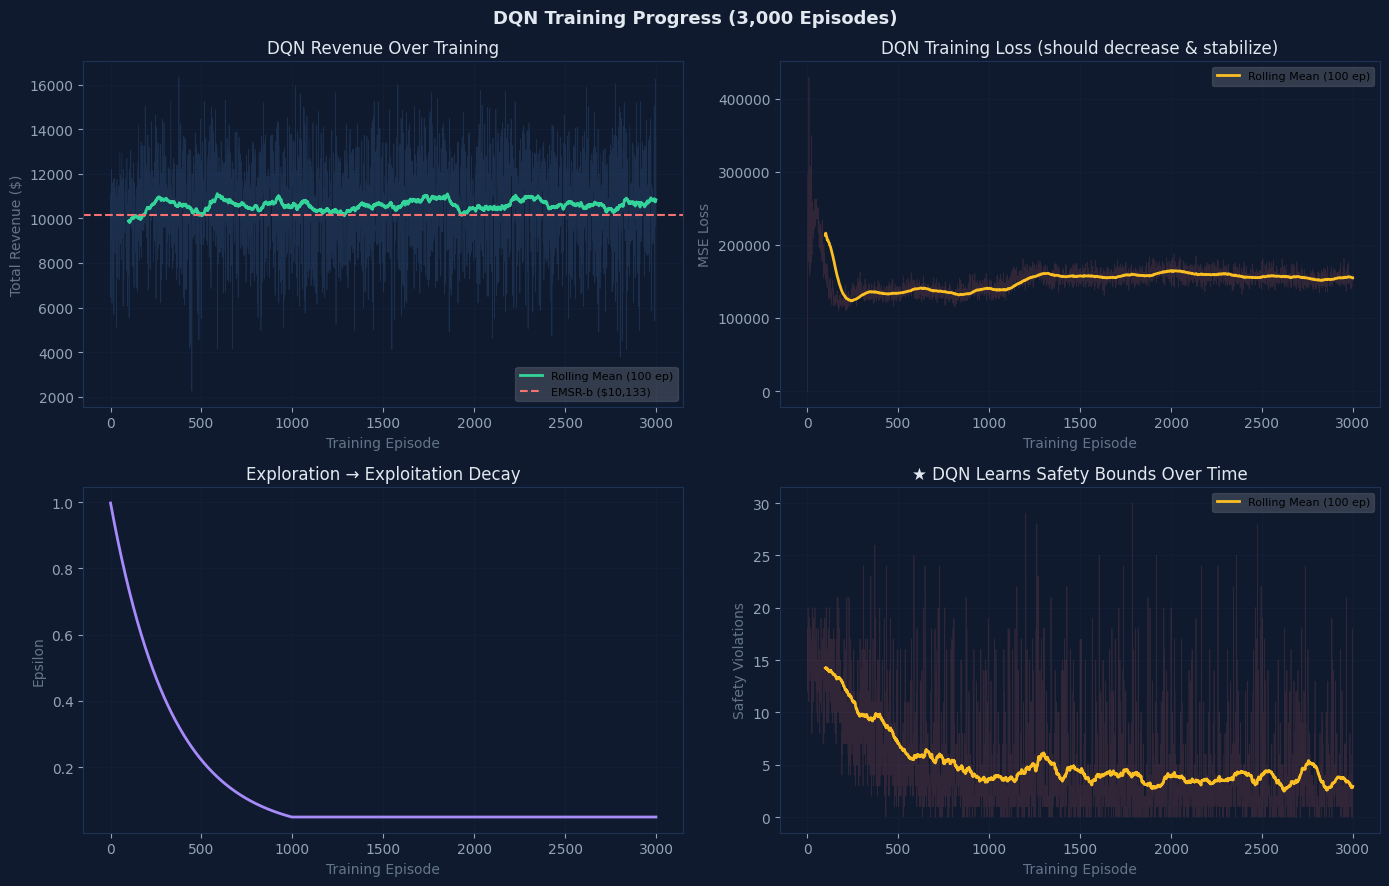

✅ Saved → reports/dqn_training.png


In [10]:
# ── CELL 10: Visualize DQN Training Progress ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#0f1a2e')
for ax in axes.flatten():
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b'); ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
# Revenue over training
rolling_rev = pd.Series(episode_revenues).rolling(100).mean()
axes[0,0].plot(episode_revenues, color='#60a5fa', alpha=0.15, linewidth=0.5)
axes[0,0].plot(rolling_rev, color='#34d399', linewidth=2, label='Rolling Mean (100 ep)')
if week2_comparison is not None:
    emsr_mean = week2_comparison.loc[
        week2_comparison['Strategy']=='EMSR-b', 'Mean Revenue'].values
    if len(emsr_mean):
        axes[0,0].axhline(emsr_mean[0], color='#f87171', linestyle='--',
                          linewidth=1.5, label=f'EMSR-b (${emsr_mean[0]:,.0f})')
axes[0,0].set_xlabel('Training Episode'); axes[0,0].set_ylabel('Total Revenue ($)')
axes[0,0].set_title('DQN Revenue Over Training')
axes[0,0].legend(fontsize=8, framealpha=0.15)
axes[0,0].grid(alpha=0.2, color='#1e3254')
 
# Training loss
rolling_loss = pd.Series(episode_losses).rolling(100).mean()
axes[0,1].plot(episode_losses, color='#f87171', alpha=0.15, linewidth=0.5)
axes[0,1].plot(rolling_loss, color='#fbbf24', linewidth=2, label='Rolling Mean (100 ep)')
axes[0,1].set_xlabel('Training Episode'); axes[0,1].set_ylabel('MSE Loss')
axes[0,1].set_title('DQN Training Loss (should decrease & stabilize)')
axes[0,1].legend(fontsize=8, framealpha=0.15)
axes[0,1].grid(alpha=0.2, color='#1e3254')
 
# Epsilon decay
axes[1,0].plot(epsilon_history, color='#a78bfa', linewidth=2)
axes[1,0].set_xlabel('Training Episode'); axes[1,0].set_ylabel('Epsilon')
axes[1,0].set_title('Exploration → Exploitation Decay')
axes[1,0].grid(alpha=0.2, color='#1e3254')
 
# Safety violations
rolling_viol = pd.Series(episode_safety).rolling(100).mean()
axes[1,1].plot(episode_safety, color='#f87171', alpha=0.15, linewidth=0.5)
axes[1,1].plot(rolling_viol, color='#fbbf24', linewidth=2, label='Rolling Mean (100 ep)')
axes[1,1].set_xlabel('Training Episode'); axes[1,1].set_ylabel('Safety Violations')
axes[1,1].set_title('★ DQN Learns Safety Bounds Over Time')
axes[1,1].legend(fontsize=8, framealpha=0.15)
axes[1,1].grid(alpha=0.2, color='#1e3254')
 
plt.suptitle(f'DQN Training Progress ({N_TRAIN_EPISODES:,} Episodes)',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/dqn_training.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/dqn_training.png")

In [11]:
# ── CELL 11: Evaluate Trained DQN Agent ──────────────────
print("Evaluating trained DQN agent over 300 episodes...")
 
env_eval = ContextualAirlinePricingEnv()
dqn_eval_revenues, dqn_eval_safety = [], []
 
for ep in tqdm(range(300), desc="DQN Eval"):
    obs, _ = env_eval.reset(seed=ep + 9000)
    done = False
    while not done:
        action_idx = dqn_agent.choose_action(obs, training=False)
        eco_idx, biz_idx = action_to_multi(action_idx)
        obs, reward, done, _, _ = env_eval.step(np.array([eco_idx, biz_idx]))
    dqn_eval_revenues.append(env_eval.total_revenue)
    dqn_eval_safety.append(env_eval.safety_violations)
 
print(f"\n✅ DQN Evaluation complete")
print(f"   Mean Revenue        : ${np.mean(dqn_eval_revenues):,.0f}")
print(f"   Std  Revenue        : ${np.std(dqn_eval_revenues):,.0f}")
print(f"   Mean Safety Blocks  : {np.mean(dqn_eval_safety):.2f} per episode")

Evaluating trained DQN agent over 300 episodes...


DQN Eval: 100%|██████████| 300/300 [00:06<00:00, 47.80it/s]


✅ DQN Evaluation complete
   Mean Revenue        : $11,106
   Std  Revenue        : $2,654
   Mean Safety Blocks  : 0.00 per episode


In [12]:
# ── CELL 12: Full Leaderboard — Including DQN ────────────
if week2_comparison is not None:
    full_leaderboard = week2_comparison.copy()
else:
    full_leaderboard = pd.DataFrame(columns=['Strategy','Mean Revenue','Std Revenue','Safety Blocks/Ep'])
 
new_row = pd.DataFrame([{
    'Strategy': 'DQN',
    'Mean Revenue': round(np.mean(dqn_eval_revenues), 0),
    'Std Revenue': round(np.std(dqn_eval_revenues), 0),
    'Safety Blocks/Ep': round(np.mean(dqn_eval_safety), 2)
}])
full_leaderboard = pd.concat([full_leaderboard[['Strategy','Mean Revenue','Std Revenue','Safety Blocks/Ep']],
                              new_row], ignore_index=True)
full_leaderboard = full_leaderboard.sort_values('Mean Revenue', ascending=False).reset_index(drop=True)
 
emsr_baseline = full_leaderboard.loc[full_leaderboard['Strategy']=='EMSR-b','Mean Revenue']
if len(emsr_baseline):
    full_leaderboard['vs EMSR-b (%)'] = (
        (full_leaderboard['Mean Revenue'] - emsr_baseline.values[0]) / emsr_baseline.values[0] * 100
    ).round(2)
 
print("=" * 75)
print("   FINAL LEADERBOARD — ALL STRATEGIES (INCLUDING DQN)")
print("=" * 75)
print(full_leaderboard.to_string(index=False))
print("=" * 75)

   FINAL LEADERBOARD — ALL STRATEGIES (INCLUDING DQN)
           Strategy  Mean Revenue  Std Revenue  Safety Blocks/Ep  vs EMSR-b (%)
        Fixed Price       11576.0       1741.0              0.00          14.24
                DQN       11106.0       2654.0              0.00           9.60
         Q-Learning       10487.0       1802.0             11.39           3.49
Time-Based Discount       10366.0       1792.0              0.00           2.30
             EMSR-b       10133.0       1617.0              0.10           0.00


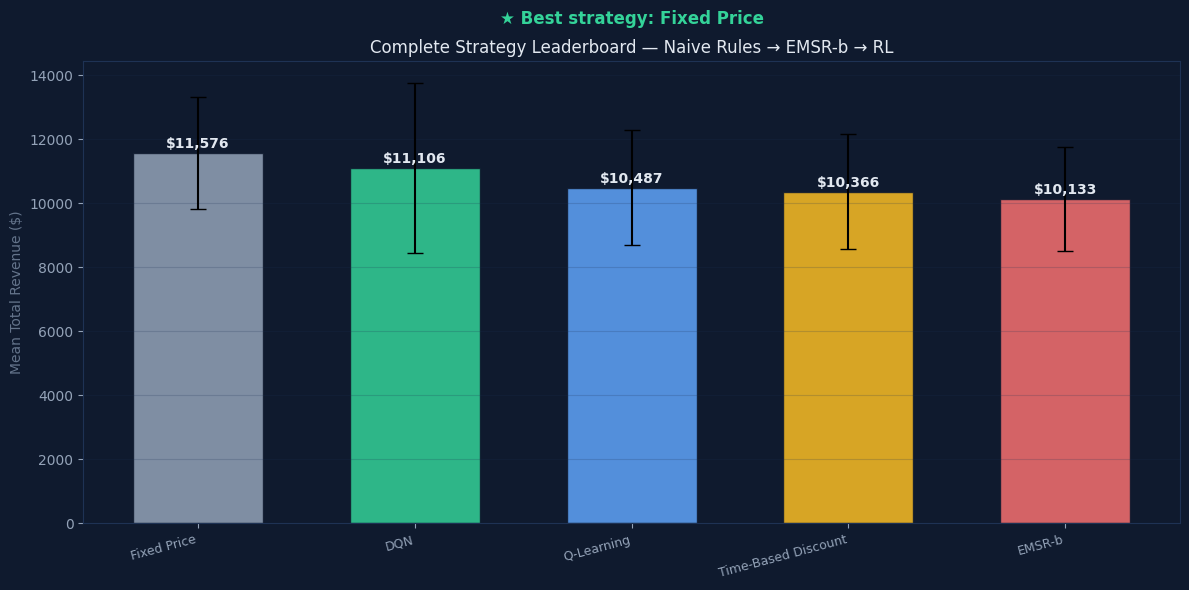

✅ Saved → reports/final_leaderboard_with_dqn.png


In [13]:
# ── CELL 13: Visualize Final Comparison ──────────────────
fig2, ax2 = plt.subplots(figsize=(12, 6))
fig2.patch.set_facecolor('#0f1a2e')
ax2.set_facecolor('#0f1a2e')
for spine in ax2.spines.values(): spine.set_edgecolor('#1e3254')
ax2.tick_params(colors='#94a3b8')
ax2.xaxis.label.set_color('#64748b'); ax2.yaxis.label.set_color('#64748b')
ax2.title.set_color('#e2e8f0')
 
strat_colors = {
    'Fixed Price':'#94a3b8', 'Time-Based Discount':'#fbbf24',
    'EMSR-b':'#f87171', 'Q-Learning':'#60a5fa', 'DQN':'#34d399'
}
colors_final = [strat_colors.get(s, '#a78bfa') for s in full_leaderboard['Strategy']]
 
bars = ax2.bar(full_leaderboard['Strategy'], full_leaderboard['Mean Revenue'],
               yerr=full_leaderboard['Std Revenue'], capsize=6,
               color=colors_final, alpha=0.85, edgecolor='#0f1a2e', width=0.6)
for bar, val in zip(bars, full_leaderboard['Mean Revenue']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+150,
             f'${val:,.0f}', ha='center', fontweight='bold',
             fontsize=10, color='#e2e8f0')
 
best = full_leaderboard.iloc[0]['Strategy']
ax2.text(0.5, 1.08, f'★ Best strategy: {best}',
         transform=ax2.transAxes, ha='center', fontsize=12,
         color='#34d399', fontweight='bold')
 
ax2.set_ylabel('Mean Total Revenue ($)')
ax2.set_title('Complete Strategy Leaderboard — Naive Rules → EMSR-b → RL')
ax2.set_xticklabels(full_leaderboard['Strategy'], rotation=15, ha='right', fontsize=9)
ax2.grid(alpha=0.2, color='#1e3254', axis='y')
 
plt.tight_layout()
plt.savefig('../reports/final_leaderboard_with_dqn.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/final_leaderboard_with_dqn.png")

In [ ]:
# ── CELL 14: DQN Price Trajectory — Learned Policy ───────
# Visualize what the TRAINED DQN actually does — the real
# proof of learned behaviour requested by the project spec:
# "proving that the agent learned complex behaviors like
#  dropping prices near the deadline to clear remaining stock"
 
env_policy = ContextualAirlinePricingEnv()
obs, _ = env_policy.reset(seed=123)
done = False
while not done:
    action_idx = dqn_agent.choose_action(obs, training=False)
    eco_idx, biz_idx = action_to_multi(action_idx)
    obs, reward, done, _, _ = env_policy.step(np.array([eco_idx, biz_idx]))
 
hist = env_policy.get_history_df()
 
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 8))
fig3.patch.set_facecolor('#0f1a2e')
for ax in axes3.flatten():
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b'); ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
axes3[0,0].plot(hist['day'], hist['eco_price'], color='#60a5fa',
                linewidth=2, marker='o', markersize=3, label='Economy')
axes3[0,0].plot(hist['day'], hist['biz_price'], color='#a78bfa',
                linewidth=2, marker='s', markersize=3, label='Business')
axes3[0,0].plot(hist['day'], hist['competitor_price'], color='#f87171',
                linewidth=1.2, linestyle='--', alpha=0.7, label='Competitor')
axes3[0,0].set_xlabel('Day'); axes3[0,0].set_ylabel('Price ($)')
axes3[0,0].set_title('★ Learned DQN Price Trajectory')
axes3[0,0].legend(fontsize=8, framealpha=0.15)
axes3[0,0].grid(alpha=0.2, color='#1e3254')
 
axes3[0,1].plot(hist['day'], hist['eco_seats_left'], color='#60a5fa',
                linewidth=2, label='Economy seats')
axes3[0,1].plot(hist['day'], hist['biz_seats_left'], color='#a78bfa',
                linewidth=2, label='Business seats')
axes3[0,1].set_xlabel('Day'); axes3[0,1].set_ylabel('Seats Remaining')
axes3[0,1].set_title('Inventory Depletion Under DQN Policy')
axes3[0,1].legend(fontsize=8, framealpha=0.15)
axes3[0,1].grid(alpha=0.2, color='#1e3254')
 
w = 0.35
axes3[1,0].bar(hist['day']-w/2, hist['eco_bookings'], width=w,
               color='#60a5fa', alpha=0.85, label='Economy', edgecolor='#0f1a2e')
axes3[1,0].bar(hist['day']+w/2, hist['biz_bookings'], width=w,
               color='#a78bfa', alpha=0.85, label='Business', edgecolor='#0f1a2e')
axes3[1,0].set_xlabel('Day'); axes3[1,0].set_ylabel('Bookings')
axes3[1,0].set_title('Daily Bookings Under DQN Policy')
axes3[1,0].legend(fontsize=8, framealpha=0.15)
axes3[1,0].grid(alpha=0.2, color='#1e3254', axis='y')
 
axes3[1,1].plot(hist['day'], hist['total_revenue'], color='#34d399', linewidth=2)
axes3[1,1].fill_between(hist['day'], hist['total_revenue'], alpha=0.15, color='#34d399')
axes3[1,1].set_xlabel('Day'); axes3[1,1].set_ylabel('Cumulative Revenue ($)')
axes3[1,1].set_title(f"Cumulative Revenue (Total: ${env_policy.total_revenue:,.0f})")
axes3[1,1].grid(alpha=0.2, color='#1e3254')
 
plt.suptitle('DQN Learned Policy — Single Episode Walkthrough',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/dqn_learned_policy.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/dqn_learned_policy.png")
 
# Check: does price drop near the deadline? (last 5 days vs first 5 days)
early_eco = hist[hist['day']<=5]['eco_price'].mean()
late_eco  = hist[hist['day']>=25]['eco_price'].mean()
print(f"\n  Behavioural check — does DQN drop prices near deadline?")
print(f"     Avg Economy price, first 5 days : ${early_eco:.0f}")
print(f"     Avg Economy price, last 5 days  : ${late_eco:.0f}")
if late_eco < early_eco:
    print(f"     ✅ Confirmed — agent learned to discount as deadline approaches")
else:
    print(f"     ℹ️  Pattern not clearly visible in this single episode "
          f"(inventory/context dependent)")